In [1]:
import pandas as pd
import numpy as np
df=pd.read_excel('/content/CleanedDataWithNewFeatures.xlsx')

In [2]:
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,Feedback_Comments,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated,Loyalty_Score_Enhanced,Customer_Segment_Label
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,3,0.706119,60,0,0,1,1,0.423671,78,1
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,3,-0.295759,29,1,1,0,1,-0.085770,27,0
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,3,-1.063724,92,0,0,2,2,-0.978626,-1,2
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,2,0.015573,62,1,1,1,2,0.009655,14,1
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,3,-1.287295,80,0,1,1,0,-1.029836,-25,2


In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Aggregation at the customer level
customer_df = df.groupby('Customer_ID').agg({
    'Purchase_Amount':'sum',
    'Purchase_Date':'count', # acts as frequency
    'Loyalty_Score':'mean'
}).rename(columns={'Purchase_Amount': 'Total_Purchase_Amount',
                   'Purchase_Date': 'Number_of_Orders',
                   'Loyalty_Score': 'Avg_Loyalty_Score'}).reset_index()



In [4]:
customer_df

,Customer_ID,Total_Purchase_Amount,Number_of_Orders,Avg_Loyalty_Score
0,10001,-2.749768e+00,2,22.0
1,10004,-4.214307e-16,1,48.0
2,10005,1.447295e+00,1,94.0
3,10009,-3.883097e-01,3,20.0
4,10011,-1.247509e+00,1,90.0
...,...,...,...,...
1795,19986,-4.214307e-16,1,74.0
1796,19989,1.105014e+00,1,95.0
1797,19991,1.101008e+00,1,31.0
1798,19996,1.433462e-01,1,2.0


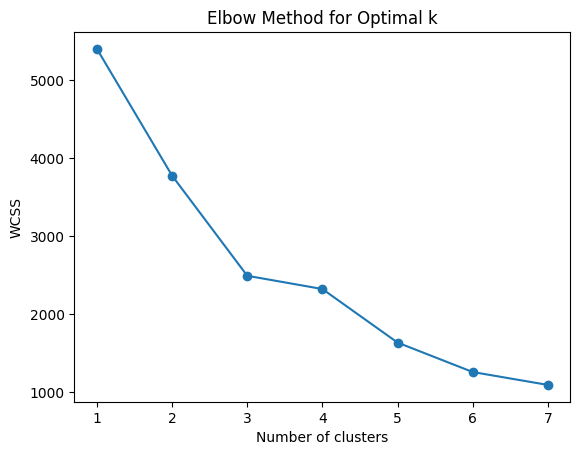

In [5]:
# Feature scaling for better clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = customer_df[['Total_Purchase_Amount', 'Number_of_Orders', 'Avg_Loyalty_Score']]
features_scaled = scaler.fit_transform(features)
wcss = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


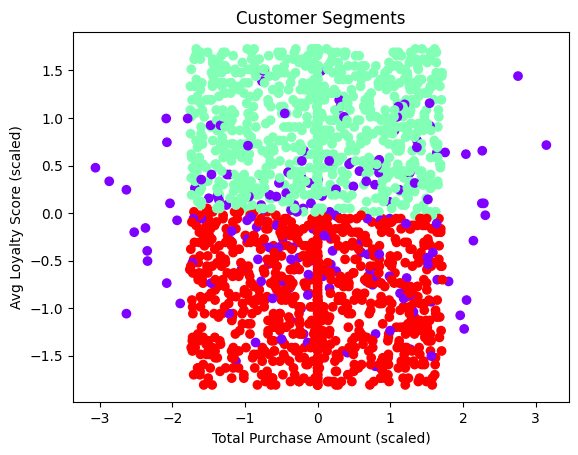

In [6]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(features_scaled)

# Visualize segments
plt.scatter(features_scaled[:, 0], features_scaled[:, 2], c=customer_df['Cluster'], cmap='rainbow')
plt.xlabel('Total Purchase Amount (scaled)')
plt.ylabel('Avg Loyalty Score (scaled)')
plt.title('Customer Segments')
plt.show()

In [7]:
# Add segment labels back to original df
df = df.merge(customer_df[['Customer_ID', 'Cluster']], on='Customer_ID', how='left')

In [8]:
df.head()

,Customer_ID,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,Rating,...,Customer_Lifetime_Value,Loyalty_Score,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,CLV_Estimated,Loyalty_Score_Enhanced,Customer_Segment_Label,Cluster
0,17270,56.0,2,3,0,674,2020-01-01 00:00:00,1.732541,1,3,...,0.706119,60,0,0,1,1,0.423671,78,1,1
1,10860,33.0,2,1,3,393,2020-01-01 01:00:00,-0.842423,1,5,...,-0.295759,29,1,1,0,1,-0.085770,27,0,2
2,15390,50.0,0,1,1,995,2020-01-01 02:00:00,-1.102093,0,3,...,-1.063724,92,0,0,2,2,-0.978626,-1,2,0
3,15191,66.0,2,4,2,405,2020-01-01 03:00:00,-0.232046,0,2,...,0.015573,62,1,1,1,2,0.009655,14,1,1
4,15734,38.0,0,3,4,353,2020-01-01 04:00:00,-1.631815,0,2,...,-1.287295,80,0,1,1,0,-1.029836,-25,2,1


### Linear regression on Customer Life time value

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Aggregate for regression (use latest loyalty, total orders, avg discounts, etc.)
regr_df = df.groupby('Customer_ID').agg({
    'Age':'mean',
    'Purchase_Amount':'sum',
    'Discount_Applied': lambda x: (x=='Yes').mean(),
    'Payment_Method': lambda x: x.mode()[0],
    'Loyalty_Score':'mean',
    'Customer_Lifetime_Value':'mean'
}).reset_index()


# Features/target
X = regr_df.drop(['Customer_ID', 'Customer_Lifetime_Value'], axis=1)
y = regr_df['Customer_Lifetime_Value']


In [10]:
X = pd.get_dummies(X, drop_first=True)

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_test = reg.predict(X_test)

# Performance metrics
print(f'R2 Score: {r2_score(y_test, y_pred_test):.2f}')
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')

# Coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg.coef_
})
print(coef_df)

R2 Score: 0.69
RMSE: 0.54
            Feature   Coefficient
0               Age  5.643124e-05
1   Purchase_Amount  7.438876e-01
2  Discount_Applied  1.665335e-16
3    Payment_Method -1.022459e-02
4     Loyalty_Score -1.192517e-03


In [13]:
comparisonLR_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print(comparisonLR_df)

        Actual  Predicted
1591  0.399188   0.156390
943   2.297866   0.779149
869   0.476372  -0.124890
162   1.526976   0.709945
1271 -1.165485  -0.892390
...        ...        ...
765  -1.131764  -0.669535
1465  0.371962  -0.315911
1734 -0.982994  -0.461048
1269  0.783111   0.361420
1274 -0.187505  -0.229383

[360 rows x 2 columns]


We have developed and trained a Linear Regression model to accurately predict Customer Lifetime Value (CLV), enabling better understanding and forecasting of customer purchasing behavior over time. The model achieved an R² score of 0.69, indicating that it explains 69% of the variability in customer lifetime value.

### Random forest classifiers to find high-CLV customers

In [14]:
import pandas as pd

# Create 3 categories using quantiles
regr_df['CLV_Class_3'] = pd.qcut(
    regr_df['Customer_Lifetime_Value'],
    q=3,  # number of bins
    labels=['Low', 'Medium', 'High']
)

# Check the distribution
print(regr_df['CLV_Class_3'].value_counts())


CLV_Class_3
Low       600
Medium    600
High      600
Name: count, dtype: int64


In [15]:
# For classification, use numerical labels if preferred
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
regr_df['CLV_Class_3'] = regr_df['CLV_Class_3'].map(label_map)

# Prepare features and target
X = regr_df.drop(['Customer_ID', 'Customer_Lifetime_Value', 'CLV_Class_3'], axis=1)
y = regr_df['CLV_Class_3']

# Encode categorical features in X (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
print("RF accuracy:", accuracy_score(y_test, y_pred_test))

RF accuracy: 0.7


In [17]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print(comparison_df)

     Actual  Predicted
1236      1          1
635       1          2
806       2          2
1453      0          0
188       2          1
...     ...        ...
1184      1          2
201       1          2
258       1          2
498       2          2
881       1          1

[360 rows x 2 columns]


We have trained a Random Forest classifier to identify high customer lifetime value (CLV) customers and offer them exclusive deals to increase retention. The model achieved an accuracy score of approximately 0.71, indicating it can correctly classify high-CLV customers about 71% of the time. The label “2” represents high-CLV (customer lifetime value) customers